In [3]:
# Prevent HuggingFace parallelism warning (recommended)
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# -------------------------
# PATHS / CONFIG
# IMPORTANT: adjust PATHS below to match your Kaggle input / working dirs.
# -------------------------
PATHS = {
    "full_release_csv":"/kaggle/input/dataset-2/Released Full Dataset-20250921T053307Z-1-001/Released Full Dataset/anonymized_full_release_competition_dataset.csv",
    "training_label":"/kaggle/input/dataset-2/Competition Training Set-20250921T053306Z-1-001/Competition Training Set/anonymized_dataset_for_ADM2017/training_label.csv",
    # where to save artifacts in working dir:
    "out_dir": "/kaggle/working"
}
os.makedirs(PATHS["out_dir"], exist_ok=True)

# -------------------------
# IMPORTS
# -------------------------
import gc
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings("ignore")

# For embeddings (LLM)
try:
    from sentence_transformers import SentenceTransformer
    have_sbert = True
except Exception as e:
    print("sentence-transformers missing or failing. LLM embedding stage will require a local snapshot or to install sentence-transformers.")
    have_sbert = False

# -------------------------
# UTIL FUNCTIONS
# -------------------------
def save_obj(obj, path):
    joblib.dump(obj, path)
    print("Saved:", path)

def load_obj(path):
    return joblib.load(path)

def safe_read_csv(path, **kwargs):
    print("Reading:", path)
    return pd.read_csv(path, low_memory=False, **kwargs)

# Helper to train and evaluate a LightGBM model
def train_eval_lgb(X_tr, y_tr, X_val, y_val, params=None, name="lam_model"):
    if params is None:
        params = dict(
            objective="binary",
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=64,
            random_state=42,
            n_jobs=-1
        )
    clf = lgb.LGBMClassifier(**params)
    clf.fit(X_tr, y_tr, eval_set=[(X_val,y_val)], verbose=50)
    probs = clf.predict_proba(X_val)[:,1]
    preds = (probs > 0.5).astype(int)
    acc = accuracy_score(y_val, preds)
    roc = roc_auc_score(y_val, probs)
    f1 = f1_score(y_val, preds, zero_division=0)
    print(f"\n{name} Results -> Acc: {acc:.4f}, ROC-AUC: {roc:.4f}, F1: {f1:.4f}")
    print(classification_report(y_val, preds, zero_division=0))
    return clf, probs, preds

2025-10-31 04:12:00.351693: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761883920.665962      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761883920.770034      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
# -------------------------
# STEP 1 & 2 — Load datasets, Merge, and Cleaning
# -------------------------
df = safe_read_csv(PATHS["full_release_csv"])
labels_df = safe_read_csv(PATHS["training_label"])

print("Full DF shape:", df.shape)
print("Labels shape:", labels_df.shape)

# Normalize column names for both dataframes for consistency
df = df.rename(columns=lambda s: s.strip())
labels_df = labels_df.rename(columns=lambda s: s.strip())

# Rename for canonical use in the main dataframe (df)
if "studentId" in df.columns:
    df = df.rename(columns={"studentId":"student_id"})
if "problemId" in df.columns:
    df = df.rename(columns={"problemId":"problem_id"})
if "skill" in df.columns:
    df = df.rename(columns={"skill":"skill_id"})

# Check and rename columns in the labels dataframe (labels_df)
# This is where the fix for the KeyError is applied:
if "problemId" in labels_df.columns: # Check for the exact case
    labels_df = labels_df.rename(columns={"problemId":"problem_id"})
elif "problemid" in labels_df.columns: # Check for lowercase
    labels_df = labels_df.rename(columns={"problemid":"problem_id"})
# Add more checks if needed, but 'problem_id' is the canonical name we need.


# CRITICAL FIX: Merge isSTEM labels BEFORE the student split.
print("Training label columns:", list(labels_df.columns))

if "isSTEM" in labels_df.columns:
    # Use the now-normalized 'problem_id' from the labels_df
    if "problem_id" in labels_df.columns:
        labels_to_merge = labels_df[["problem_id", "isSTEM"]].drop_duplicates()
        df = df.merge(labels_to_merge, on="problem_id", how="left")
        print("isSTEM labels merged.")
    else:
        print("Error: Cannot find 'problem_id' in labels_df after initial cleaning. Skipping iSTEM merge.")
        
# Keep only rows with essential fields
df = df.dropna(subset=["student_id","skill_id","problem_id","correct"])
df["correct"] = df["correct"].astype(int)
# convert times safely
if "startTime" in df.columns:
    df["startTime"] = pd.to_datetime(df["startTime"], errors="coerce")

# Sort for temporal operations (CRITICAL for causality)
df = df.sort_values(["student_id","startTime"]).reset_index(drop=True)

print("After cleaning and merging shape:", df.shape)

Reading: /kaggle/input/dataset-2/Released Full Dataset-20250921T053307Z-1-001/Released Full Dataset/anonymized_full_release_competition_dataset.csv
Reading: /kaggle/input/dataset-2/Competition Training Set-20250921T053306Z-1-001/Competition Training Set/anonymized_dataset_for_ADM2017/training_label.csv
Full DF shape: (942816, 82)
Labels shape: (514, 5)
Training label columns: ['ITEST_id', 'SchoolId', 'AveCorrect', 'MCAS', 'isSTEM']
Error: Cannot find 'problem_id' in labels_df after initial cleaning. Skipping iSTEM merge.
After cleaning and merging shape: (942816, 82)


In [10]:
# -------------------------
# UPDATED UTIL FUNCTION (MUST BE RUN IF NOT IN PREVIOUS CELL)
# -------------------------
import lightgbm as lgb # Ensure this is imported

def train_eval_lgb(X_tr, y_tr, X_val, y_val, params=None, name="lam_model"):
    if params is None:
        params = dict(
            objective="binary",
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=64,
            random_state=42,
            n_jobs=-1
        )
    clf = lgb.LGBMClassifier(**params)
    
    # Use callbacks for verbosity (fixes TypeError)
    clf.fit(X_tr, y_tr, 
            eval_set=[(X_val,y_val)], 
            eval_metric="auc", 
            callbacks=[lgb.log_evaluation(period=50)])
            
    probs = clf.predict_proba(X_val)[:,1]
    preds = (probs > 0.5).astype(int)
    acc = accuracy_score(y_val, preds)
    roc = roc_auc_score(y_val, probs)
    f1 = f1_score(y_val, preds, zero_division=0)
    print(f"\n{name} Results -> Acc: {acc:.4f}, ROC-AUC: {roc:.4f}, F1: {f1:.4f}")
    print(classification_report(y_val, preds, zero_division=0))
    return clf, probs, preds

# -------------------------
# STEP 3 — Build leak-free aggregated features (Assumed completed successfully)
# -------------------------
# Assuming df is available and features are created/scaled.
# If starting from here, ensure 'df' and 'fusion_feature_cols' are in memory.

# -------------------------
# STEP 4 — Train/Val split (Assumed completed successfully)
# -------------------------
# Assuming train_df, val_df, y_train, y_val are defined.

# -------------------------
# STEP 5 — LAM: LightGBM model (SAFE & LEAKY)
# -------------------------
# Define feature sets
lam_features_leaky = fusion_feature_cols + ["startTime","totalTimeByPercentCorrectForskill","timeGreater10SecAndNextActionRight"]
lam_features_safe  = fusion_feature_cols

# CRITICAL FIX: Convert 'startTime' to numeric for LightGBM (fixes DTypePromotionError)
if "startTime" in train_df.columns and train_df["startTime"].dtype.kind == 'M': # 'M' for datetime
    # Convert to Unix epoch seconds (np.int64 // 10**9)
    train_df["startTime_numeric"] = train_df["startTime"].astype(np.int64) // 10**9
    val_df["startTime_numeric"] = val_df["startTime"].astype(np.int64) // 10**9
    
    # Update the leaky features list to use the new numeric column
    lam_features_leaky = [f if f != "startTime" else "startTime_numeric" for f in lam_features_leaky]
    
    # Fill the new numeric column
    train_df["startTime_numeric"] = train_df["startTime_numeric"].fillna(0)
    val_df["startTime_numeric"] = val_df["startTime_numeric"].fillna(0)
    print("Fixed 'startTime' DType by converting to numeric Unix epoch.")


# Ensure all leaky features exist (including the converted one if applicable)
for f in lam_features_leaky:
    if f not in train_df.columns:
        train_df[f] = 0
        val_df[f] = 0

# Prepare labels (correct)
y_train = train_df["correct"]
y_val   = val_df["correct"]

# Train LEAKY LAM (FOR DIAGNOSTICS - expected high ROC-AUC due to leakage)
X_tr_leaky = train_df[lam_features_leaky].fillna(0)
X_val_leaky = val_df[lam_features_leaky].fillna(0)
leaky_clf, leaky_probs, leaky_preds = train_eval_lgb(X_tr_leaky, y_train, X_val_leaky, y_val, name="LAM_LEAKY_DIAGNOSTIC")

# Train SAFE LAM (REALISTIC MODEL - expected 0.80 - 0.87 ROC-AUC)
X_tr_safe = train_df[lam_features_safe].fillna(0)
X_val_safe = val_df[lam_features_safe].fillna(0)
safe_clf, safe_probs, safe_preds = train_eval_lgb(X_tr_safe, y_train, X_val_safe, y_val, name="LAM_SAFE_BASE")

# Save LAM models
save_obj(leaky_clf, os.path.join(PATHS["out_dir"], "lam_leaky_lgb.pkl"))
save_obj(safe_clf, os.path.join(PATHS["out_dir"], "lam_safe_lgb.pkl"))

Fixed 'startTime' DType by converting to numeric Unix epoch.
[LightGBM] [Info] Number of positive: 298338, number of negative: 499780
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1929
[LightGBM] [Info] Number of data points in the train set: 798118, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373802 -> initscore=-0.515941
[LightGBM] [Info] Start training from score -0.515941
[50]	valid_0's auc: 0.970997	valid_0's binary_logloss: 0.272597
[100]	valid_0's auc: 0.972662	valid_0's binary_logloss: 0.210237
[150]	valid_0's auc: 0.973355	valid_0's binary_logloss: 0.195608
[200]	valid_0's auc: 0.973725	valid_0's binary_logloss: 0.191401
[250]	valid_0's auc: 0.973859	valid_0's binary_logloss: 0.190229
[300]	valid_0's auc: 0.973906	valid_0's binary_logloss

In [11]:
# -------------------------
# Step 6 & 7 — LLM: Get embeddings & Fusion Prep
# -------------------------
LOCAL_SNAPSHOT = None  # Set this if you downloaded MiniLM locally
text_column = "original" if "original" in df.columns else "problem_text" if "problem_text" in df.columns else None
if text_column is None:
    # fallback: build a tiny text from skill/problem
    df["original"] = df["skill_id"].astype(str) + " " + df["problem_id"].astype(str)
    text_column = "original"

# Use val+train combined order consistent with fusion later
all_texts = pd.concat([train_df[[text_column]].reset_index(drop=True),
                       val_df[[text_column]].reset_index(drop=True)], axis=0, ignore_index=True)

model = None
emb_dim = 384 # Default MiniLM dimension
if have_sbert:
    try:
        print("\nLoading SentenceTransformer (paraphrase-MiniLM-L6-v2)...")
        # NOTE: This may require a working internet connection or a locally downloaded model in Kaggle
        model = SentenceTransformer("paraphrase-MiniLM-L6-v2")
    except Exception as e:
        print(f"Could not load remote MiniLM. Error: {e}. Trying local snapshot.")
        if LOCAL_SNAPSHOT is not None:
            model = SentenceTransformer(LOCAL_SNAPSHOT, local_files_only=True)
        else:
            print("No local snapshot. Skipping LLM embeddings.")

llm_embeddings = None
if model is not None:
    batch_size = 256
    print("Generating embeddings (this can take time)...")
    llm_embeddings = model.encode(all_texts[text_column].astype(str).tolist(), show_progress_bar=True, batch_size=batch_size)
    np.save(os.path.join(PATHS["out_dir"], "LLM_Embeddings.npy"), llm_embeddings)
    emb_dim = llm_embeddings.shape[1]
    print("LLM embeddings shape:", llm_embeddings.shape)

# Fusion: combine SAFE-LAM output + LLM embeddings
lam_safe_row_probs_train = safe_clf.predict_proba(X_tr_safe)[:,1]
lam_safe_row_probs_val   = safe_clf.predict_proba(X_val_safe)[:,1]

fusion_train_rows = train_df.copy()
fusion_val_rows   = val_df.copy()

fusion_train_rows["lam_safe_prob"] = lam_safe_row_probs_train
fusion_val_rows["lam_safe_prob"]   = lam_safe_row_probs_val

if llm_embeddings is not None:
    n_tr = len(fusion_train_rows)
    emb_tr = llm_embeddings[:n_tr]
    emb_val = llm_embeddings[n_tr:n_tr + len(fusion_val_rows)]
    np.save(os.path.join(PATHS["out_dir"], "LLM_emb_tr.npy"), emb_tr)
    np.save(os.path.join(PATHS["out_dir"], "LLM_emb_val.npy"), emb_val)
else:
    print(f"Using {emb_dim} placeholder zeros for LLM embeddings (LLM features skipped).")
    emb_tr = np.zeros((len(fusion_train_rows), emb_dim))
    emb_val = np.zeros((len(fusion_val_rows), emb_dim))

# Build final fusion arrays (rows x features)
X_fusion_train = np.hstack([fusion_train_rows[fusion_feature_cols].values, fusion_train_rows[["lam_safe_prob"]].values, emb_tr])
X_fusion_val   = np.hstack([fusion_val_rows[fusion_feature_cols].values, fusion_val_rows[["lam_safe_prob"]].values, emb_val])

print("Fusion shapes train/val:", X_fusion_train.shape, X_fusion_val.shape)


Loading SentenceTransformer (paraphrase-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

Could not load remote MiniLM. Error: 404 Client Error. (Request ID: Root=1-690439e5-710f85512414b23c2c028401;3b39c611-0cc2-404a-9800-1d36d42d23d4)

Entry Not Found for url: https://huggingface.co/api/models/sentence-transformers/paraphrase-MiniLM-L6-v2/tree/main/additional_chat_templates?recursive=false&expand=false.
additional_chat_templates does not exist on "main". Trying local snapshot.
No local snapshot. Skipping LLM embeddings.
Using 384 placeholder zeros for LLM embeddings (LLM features skipped).
Fusion shapes train/val: (798118, 394) (144698, 394)


In [14]:
# -------------------------
# Step 8 — Final iSTEM labeling & training (Target: isSTEM)
# -------------------------
print("\n--- iSTEM Model Training (Fusion) ---")

if "isSTEM" in train_df.columns and "isSTEM" in val_df.columns:
    
    # CRITICAL FIX: Filter out rows where the 'isSTEM' label is NaN
    mask_train = train_df["isSTEM"].notna()
    mask_val = val_df["isSTEM"].notna()

    # Filter the target labels and convert to integer
    y_istem_train = train_df.loc[mask_train, "isSTEM"].values.astype(int)
    y_istem_val = val_df.loc[mask_val, "isSTEM"].values.astype(int)
    
    # Filter the fusion feature arrays (NumPy arrays) using the boolean masks
    X_tr_istem = X_fusion_train[mask_train.values]
    X_val_istem = X_fusion_val[mask_val.values]

    if X_tr_istem.shape[0] == 0:
        # This will happen if the initial merge was completely unsuccessful
        print("iSTEM model skipped: No rows in training set have a valid 'isSTEM' label.")
    else:
        print(f"iSTEM training data filtered: Train rows={X_tr_istem.shape[0]}, Val rows={X_val_istem.shape[0]}")
        
        # simple classifier (LightGBM)
        params = dict(objective="binary",
                      n_estimators=200,
                      learning_rate=0.05,
                      num_leaves=64,
                      random_state=42,
                      n_jobs=-1)
        
        istem_clf = lgb.LGBMClassifier(**params)
        
        # Train on the filtered, NaN-free data
        istem_clf.fit(X_tr_istem, y_istem_train, 
                      eval_set=[(X_val_istem, y_istem_val)], 
                      eval_metric="auc", 
                      callbacks=[lgb.log_evaluation(period=50)])
        
        probs_istem = istem_clf.predict_proba(X_val_istem)[:,1]
        preds_istem = (probs_istem > 0.5).astype(int)
        print("\nFinal iSTEM Model Evaluation:")
        print("Acc:", accuracy_score(y_istem_val, preds_istem), "ROC:", roc_auc_score(y_istem_val, probs_istem))
        print(classification_report(y_istem_val, preds_istem, zero_division=0))
        save_obj(istem_clf, os.path.join(PATHS["out_dir"], "final_iSTEM_model.pkl"))
else:
    print("iSTEM model skipped: The target 'isSTEM' column was not found after the initial data merge.")

# -------------------------
# Step 9 — Diagnostics to reveal leakage
# -------------------------
print("\nDIAGNOSTICS:")

# 1. Student overlap check (MUST BE 0)
train_stu = set(train_df["student_id"].unique())
val_stu = set(val_df["student_id"].unique())
overlap = train_stu.intersection(val_stu)
print("Student overlap between train & val:", len(overlap))

# 2. Correlation between each candidate feature and 'correct'
# FIX: Use fusion_train_rows and fusion_val_rows which contain "lam_safe_prob"
if 'fusion_train_rows' in locals() and 'fusion_val_rows' in locals():
    all_corr_cols = fusion_feature_cols + ["lam_safe_prob"]
    
    # Concatenate the features used in the correlation check
    comb_X = pd.concat([fusion_train_rows[all_corr_cols], fusion_val_rows[all_corr_cols]], axis=0).reset_index(drop=True)
    
    # Concatenate the target variable 'correct'
    comb_y = pd.concat([fusion_train_rows["correct"], fusion_val_rows["correct"]], axis=0).reset_index(drop=True)

    corrs = pd.DataFrame(comb_X).corrwith(comb_y)
    top_corr = corrs.abs().sort_values(ascending=False).head(15)
    print("Top correlations with 'correct' (absolute):\n", top_corr)
else:
    print("Warning: Skipping correlation diagnostics. fusion_train_rows or fusion_val_rows not found.")


# 3. Label shuffle test (on the realistic leak-free fusion)
if len(X_tr_safe) > 10 and len(X_val_safe) > 0:
    import random
    y_shuffled = np.random.permutation(y_train)
    params = dict(objective="binary", n_estimators=400, learning_rate=0.03, num_leaves=64, random_state=42, n_jobs=-1)
    clf_shuf = lgb.LGBMClassifier(**params)
    clf_shuf.fit(X_tr_safe, y_shuffled) 
    
    p_shuf = clf_shuf.predict_proba(X_val_safe)[:,1]
    # Check if this result is close to 0.5 (random guess)
    print("ROC after label shuffle (should be ~0.5):", roc_auc_score(y_val, p_shuf))
else:
    print("Not enough rows for label-shuffle test.")

# Save important artifacts
np.save(os.path.join(PATHS["out_dir"], "X_fusion_train.npy"), X_fusion_train)
np.save(os.path.join(PATHS["out_dir"], "X_fusion_val.npy"), X_fusion_val)
fusion_meta = dict(fusion_feature_cols=fusion_feature_cols)
save_obj(fusion_meta, os.path.join(PATHS["out_dir"], "fusion_meta.pkl"))

print("\nALL DONE. The LAM_SAFE model is successful.")


--- iSTEM Model Training (Fusion) ---
iSTEM training data filtered: Train rows=271295, Val rows=45679
[LightGBM] [Info] Number of positive: 52507, number of negative: 218788
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1911
[LightGBM] [Info] Number of data points in the train set: 271295, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193542 -> initscore=-1.427157
[LightGBM] [Info] Start training from score -1.427157
[50]	valid_0's auc: 0.619685	valid_0's binary_logloss: 0.769058
[100]	valid_0's auc: 0.630341	valid_0's binary_logloss: 0.982802
[150]	valid_0's auc: 0.606634	valid_0's binary_logloss: 1.10157
[200]	valid_0's auc: 0.598648	valid_0's binary_logloss: 1.14386

Final iSTEM Model Evaluation:
Acc: 0.7038026226493574 ROC: 0.5986483172344603
 

In [15]:
import os
from huggingface_hub import snapshot_download

MODEL_NAME = "sentence-transformers/paraphrase-MiniLM-L6-v2"
LOCAL_MODEL_DIR = "/kaggle/working/llm_cache/paraphrase-MiniLM-L6-v2"

# 1. Check if the model directory already exists
if os.path.isdir(LOCAL_MODEL_DIR):
    print(f"✅ Model found locally at: {LOCAL_MODEL_DIR}")
else:
    print(f"Attempting to download {MODEL_NAME} to {LOCAL_MODEL_DIR}...")
    try:
        # Use snapshot_download to get all files for the model
        downloaded_path = snapshot_download(
            repo_id=MODEL_NAME,
            local_dir=LOCAL_MODEL_DIR,
            # Ignore the "model.safetensors" if using an older version of the library
            ignore_patterns=["*.safetensors"] 
        )
        print(f"✅ Download successful. Files saved to: {downloaded_path}")
    except Exception as e:
        print(f"❌ Download failed. You must ensure the notebook has internet enabled and try again.")
        print(f"Error: {e}")

# 2. Update the LOCAL_SNAPSHOT variable in your LLM/Fusion block
# You can now proceed to run the corrected Block 4 from the previous turn, 
# ensuring you set: LOCAL_SNAPSHOT = LOCAL_MODEL_DIR

Attempting to download sentence-transformers/paraphrase-MiniLM-L6-v2 to /kaggle/working/llm_cache/paraphrase-MiniLM-L6-v2...


Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/744 [00:00<?, ?B/s]

onnx/model.onnx:   0%|          | 0.00/90.4M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tf_model.h5:   0%|          | 0.00/91.0M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ Download successful. Files saved to: /kaggle/working/llm_cache/paraphrase-MiniLM-L6-v2


In [16]:
# -------------------------
# Step 6 & 7 — LLM: Get embeddings & Fusion Prep (Final Attempt)
# -------------------------
# CRITICAL: Path updated to your successful download location
LOCAL_SNAPSHOT = "/kaggle/working/llm_cache/paraphrase-MiniLM-L6-v2"  
TEXT_MODEL_NAME = "paraphrase-MiniLM-L6-v2"

# 1. Identify text column
text_column = "original" if "original" in df.columns else "problem_text" if "problem_text" in df.columns else None
if text_column is None:
    df["original"] = df["skill_id"].astype(str) + " " + df["problem_id"].astype(str)
    text_column = "original"

# 2. Combine all texts for embedding generation
all_texts = pd.concat([train_df[[text_column]].reset_index(drop=True),
                       val_df[[text_column]].reset_index(drop=True)], axis=0, ignore_index=True)

model = None
emb_dim = 384 # Default MiniLM dimension

try:
    from sentence_transformers import SentenceTransformer
    have_sbert = True
except ImportError:
    have_sbert = False

if have_sbert:
    # Prioritizing local load now that the files are present
    if LOCAL_SNAPSHOT is not None:
        try:
            print(f"\nAttempting to load local snapshot from: {LOCAL_SNAPSHOT}...")
            # local_files_only=True forces it to avoid network
            model = SentenceTransformer(LOCAL_SNAPSHOT, local_files_only=True) 
            print("✅ Successfully loaded SentenceTransformer from local path.")
        except Exception as e:
            print(f"Failed to load local snapshot. Falling back to zero embeddings. Error: {e}")
            model = None
    
# 3. Generate Embeddings or Zeros
llm_embeddings = None
if model is not None:
    batch_size = 256
    print("Generating LLM embeddings (this can take time)...")
    llm_embeddings = model.encode(all_texts[text_column].astype(str).tolist(), show_progress_bar=True, batch_size=batch_size)
    np.save(os.path.join(PATHS["out_dir"], "LLM_Embeddings.npy"), llm_embeddings)
    emb_dim = llm_embeddings.shape[1]
    print("LLM embeddings shape:", llm_embeddings.shape)
else:
    print(f"LLM Embeddings failed/skipped. Using {emb_dim} placeholder zeros for LLM features.")
    
# 4. Fusion Prep: Add LAM probability and combine features
lam_safe_row_probs_train = safe_clf.predict_proba(X_tr_safe)[:,1]
lam_safe_row_probs_val   = safe_clf.predict_proba(X_val_safe)[:,1]

fusion_train_rows = train_df.copy()
fusion_val_rows   = val_df.copy()

fusion_train_rows["lam_safe_prob"] = lam_safe_row_probs_train
fusion_val_rows["lam_safe_prob"]   = lam_safe_row_probs_val

if llm_embeddings is not None:
    n_tr = len(fusion_train_rows)
    emb_tr = llm_embeddings[:n_tr]
    emb_val = llm_embeddings[n_tr:n_tr + len(fusion_val_rows)]
    np.save(os.path.join(PATHS["out_dir"], "LLM_emb_tr.npy"), emb_tr)
    np.save(os.path.join(PATHS["out_dir"], "LLM_emb_val.npy"), emb_val)
else:
    emb_tr = np.zeros((len(fusion_train_rows), emb_dim))
    emb_val = np.zeros((len(fusion_val_rows), emb_dim))

# Build final fusion arrays (rows x features)
# The shape should now be (rows, 9 + 1 + 384) = (rows, 394)
X_fusion_train = np.hstack([fusion_train_rows[fusion_feature_cols].values, fusion_train_rows[["lam_safe_prob"]].values, emb_tr])
X_fusion_val   = np.hstack([fusion_val_rows[fusion_feature_cols].values, fusion_val_rows[["lam_safe_prob"]].values, emb_val])

print("Fusion shapes train/val:", X_fusion_train.shape, X_fusion_val.shape)


Attempting to load local snapshot from: /kaggle/working/llm_cache/paraphrase-MiniLM-L6-v2...
✅ Successfully loaded SentenceTransformer from local path.
Generating LLM embeddings (this can take time)...


Batches:   0%|          | 0/3683 [00:00<?, ?it/s]

LLM embeddings shape: (942816, 384)
Fusion shapes train/val: (798118, 394) (144698, 394)


In [17]:
# -------------------------
# Step 8 — Final iSTEM labeling & training (Target: isSTEM)
# -------------------------
print("\n--- iSTEM Model Training (Fusion) ---")

if "isSTEM" in train_df.columns and "isSTEM" in val_df.columns:
    
    # Filter out rows where the 'isSTEM' label is NaN
    mask_train = train_df["isSTEM"].notna()
    mask_val = val_df["isSTEM"].notna()

    # Filter the target labels and convert to integer
    y_istem_train = train_df.loc[mask_train, "isSTEM"].values.astype(int)
    y_istem_val = val_df.loc[mask_val, "isSTEM"].values.astype(int)
    
    # Filter the fusion feature arrays (NumPy arrays) using the boolean masks
    # X_fusion_train now contains the LLM embeddings
    X_tr_istem = X_fusion_train[mask_train.values]
    X_val_istem = X_fusion_val[mask_val.values]

    if X_tr_istem.shape[0] == 0:
        print("iSTEM model skipped: No rows in training set have a valid 'isSTEM' label.")
    else:
        print(f"iSTEM training data filtered: Train rows={X_tr_istem.shape[0]}, Val rows={X_val_istem.shape[0]}")
        
        # simple classifier (LightGBM)
        params = dict(objective="binary",
                      n_estimators=200,
                      learning_rate=0.05,
                      num_leaves=64,
                      random_state=42,
                      n_jobs=-1)
        
        istem_clf = lgb.LGBMClassifier(**params)
        
        # Train on the filtered, NaN-free data with full fusion features (LAM + LLM)
        istem_clf.fit(X_tr_istem, y_istem_train, 
                      eval_set=[(X_val_istem, y_istem_val)], 
                      eval_metric="auc", 
                      callbacks=[lgb.log_evaluation(period=50)])
        
        probs_istem = istem_clf.predict_proba(X_val_istem)[:,1]
        preds_istem = (probs_istem > 0.5).astype(int)
        print("\nFinal iSTEM Model Evaluation (with LLM features):")
        print("Acc:", accuracy_score(y_istem_val, preds_istem), "ROC:", roc_auc_score(y_istem_val, probs_istem))
        print(classification_report(y_istem_val, preds_istem, zero_division=0))
        save_obj(istem_clf, os.path.join(PATHS["out_dir"], "final_iSTEM_model_fusion.pkl"))
else:
    print("iSTEM model skipped: The target 'isSTEM' column was not found after the initial data merge.")

# -------------------------
# Step 9 — Diagnostics to reveal leakage (Final Check)
# -------------------------
print("\nDIAGNOSTICS (Confirming Leak-Free Pipeline):")

# 1. Student overlap check (MUST BE 0)
train_stu = set(train_df["student_id"].unique())
val_stu = set(val_df["student_id"].unique())
overlap = train_stu.intersection(val_stu)
print("Student overlap between train & val:", len(overlap))

# 2. Correlation between each candidate feature and 'correct'
if 'fusion_train_rows' in locals() and 'fusion_val_rows' in locals():
    all_corr_cols = fusion_feature_cols + ["lam_safe_prob"]
    
    comb_X = pd.concat([fusion_train_rows[all_corr_cols], fusion_val_rows[all_corr_cols]], axis=0).reset_index(drop=True)
    comb_y = pd.concat([fusion_train_rows["correct"], fusion_val_rows["correct"]], axis=0).reset_index(drop=True)

    corrs = pd.DataFrame(comb_X).corrwith(comb_y)
    top_corr = corrs.abs().sort_values(ascending=False).head(15)
    print("Top correlations with 'correct' (absolute):\n", top_corr)
else:
    print("Warning: Skipping correlation diagnostics. fusion_train_rows or fusion_val_rows not found.")


# 3. Label shuffle test (on the realistic leak-free fusion)
if len(X_tr_safe) > 10 and len(X_val_safe) > 0:
    y_shuffled = np.random.permutation(y_train)
    params = dict(objective="binary", n_estimators=400, learning_rate=0.03, num_leaves=64, random_state=42, n_jobs=-1)
    clf_shuf = lgb.LGBMClassifier(**params)
    clf_shuf.fit(X_tr_safe, y_shuffled) 
    
    p_shuf = clf_shuf.predict_proba(X_val_safe)[:,1]
    print("ROC after label shuffle (should be ~0.5):", roc_auc_score(y_val, p_shuf))
else:
    print("Not enough rows for label-shuffle test.")

# Save important artifacts
np.save(os.path.join(PATHS["out_dir"], "X_fusion_train.npy"), X_fusion_train)
np.save(os.path.join(PATHS["out_dir"], "X_fusion_val.npy"), X_fusion_val)
fusion_meta = dict(fusion_feature_cols=fusion_feature_cols)
save_obj(fusion_meta, os.path.join(PATHS["out_dir"], "fusion_meta.pkl"))

print("\nALL DONE. Pipeline complete and models saved.")


--- iSTEM Model Training (Fusion) ---
iSTEM training data filtered: Train rows=271295, Val rows=45679
[LightGBM] [Info] Number of positive: 52507, number of negative: 218788
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3063
[LightGBM] [Info] Number of data points in the train set: 271295, number of used features: 394
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193542 -> initscore=-1.427157
[LightGBM] [Info] Start training from score -1.427157
[50]	valid_0's auc: 0.619685	valid_0's binary_logloss: 0.769058
[100]	valid_0's auc: 0.630341	valid_0's binary_logloss: 0.982802
[150]	valid_0's auc: 0.629243	valid_0's binary_logloss: 1.03499
[200]	valid_0's auc: 0.608	valid_0's binary_logloss: 1.10442

Final iSTEM Model Evaluation (with LLM features):
Acc: 0.7120777600210162 ROC: 0.

In [18]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# -------------------------
# Step 8 — Final iSTEM labeling & training (Imbalance Corrected)
# -------------------------
print("\n--- iSTEM Model Retraining (Imbalance Corrected) ---")

if "isSTEM" in train_df.columns and "isSTEM" in val_df.columns:
    
    # Filter out rows where the 'isSTEM' label is NaN
    mask_train = train_df["isSTEM"].notna()
    mask_val = val_df["isSTEM"].notna()

    y_istem_train = train_df.loc[mask_train, "isSTEM"].values.astype(int)
    y_istem_val = val_df.loc[mask_val, "isSTEM"].values.astype(int)
    
    X_tr_istem = X_fusion_train[mask_train.values]
    X_val_istem = X_fusion_val[mask_val.values]

    if X_tr_istem.shape[0] == 0:
        print("iSTEM model skipped: No valid 'isSTEM' labels found.")
    else:
        print(f"iSTEM training data filtered: Train rows={X_tr_istem.shape[0]}, Val rows={X_val_istem.shape[0]}")
        
        # --- NEW PARAMETERS FOR IMBALANCE CORRECTION ---
        # scale_pos_weight = 4.167
        params = dict(objective="binary",
                      n_estimators=400,                   # Increased estimators
                      learning_rate=0.03,                 # Slower learning rate
                      num_leaves=64,
                      random_state=42,
                      n_jobs=-1,
                      scale_pos_weight=4.167)            # CRITICAL IMBALANCE FIX
        
        istem_clf = lgb.LGBMClassifier(**params)
        
        # Train on the filtered, NaN-free data with full fusion features (LAM + LLM)
        istem_clf.fit(X_tr_istem, y_istem_train, 
                      eval_set=[(X_val_istem, y_istem_val)], 
                      eval_metric="auc", 
                      callbacks=[lgb.log_evaluation(period=50)])
        
        probs_istem = istem_clf.predict_proba(X_val_istem)[:,1]
        preds_istem = (probs_istem > 0.5).astype(int)
        
        # NOTE: Focus on ROC and F1, not just raw Accuracy
        print("\nFinal iSTEM Model Evaluation (Imbalance Corrected):")
        print("Acc:", accuracy_score(y_istem_val, preds_istem), "ROC:", roc_auc_score(y_istem_val, probs_istem))
        print(classification_report(y_istem_val, preds_istem, zero_division=0))
        save_obj(istem_clf, os.path.join(PATHS["out_dir"], "final_iSTEM_model_fusion_tuned.pkl"))
else:
    print("iSTEM model skipped: The target 'isSTEM' column was not found.")


--- iSTEM Model Retraining (Imbalance Corrected) ---
iSTEM training data filtered: Train rows=271295, Val rows=45679
[LightGBM] [Info] Number of positive: 52507, number of negative: 218788
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3063
[LightGBM] [Info] Number of data points in the train set: 271295, number of used features: 394
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193542 -> initscore=-1.427157
[LightGBM] [Info] Start training from score -1.427157
[50]	valid_0's auc: 0.602513	valid_0's binary_logloss: 0.690759
[100]	valid_0's auc: 0.56999	valid_0's binary_logloss: 0.854088
[150]	valid_0's auc: 0.571742	valid_0's binary_logloss: 0.942692
[200]	valid_0's auc: 0.560393	valid_0's binary_logloss: 0.989272
[250]	valid_0's auc: 0.566795	valid_0's binary_logloss: 1.02934

In [21]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# -------------------------
# Step 8 — Final iSTEM labeling & training (Final Robust Tune)
# -------------------------
print("\n--- iSTEM Model Retraining (Final Robust Tune) ---")

# --- DATA PREP (Same as before) ---
mask_train = train_df["isSTEM"].notna()
mask_val = val_df["isSTEM"].notna()
y_istem_train = train_df.loc[mask_train, "isSTEM"].values.astype(int)
y_istem_val = val_df.loc[mask_val, "isSTEM"].values.astype(int)
X_tr_istem = X_fusion_train[mask_train.values]
X_val_istem = X_fusion_val[mask_val.values]

if X_tr_istem.shape[0] == 0:
    print("iSTEM model skipped: No valid 'isSTEM' labels found.")
else:
    print(f"iSTEM training data filtered: Train rows={X_tr_istem.shape[0]}, Val rows={X_val_istem.shape[0]}")
    
    # --- ROBUST PARAMETERS (Aggressive Learning + Imbalance Fix) ---
    params = dict(objective="binary",
                  n_estimators=400,                   # Stable number of iterations
                  learning_rate=0.05,                 # Aggressive learning for better feature utilization
                  num_leaves=64,                      # Stable complexity
                  random_state=42,
                  n_jobs=-1,
                  scale_pos_weight=4.167)            # CRITICAL Imbalance Fix Maintained
    
    istem_clf = lgb.LGBMClassifier(**params)
    
    print("Starting training with 400 fixed estimators...")
    
    # --- NO EARLY STOPPING ---
    istem_clf.fit(X_tr_istem, y_istem_train, 
                  eval_set=[(X_val_istem, y_istem_val)], 
                  eval_metric="auc", 
                  callbacks=[lgb.log_evaluation(period=100)])
    
    probs_istem = istem_clf.predict_proba(X_val_istem)[:,1]
    preds_istem = (probs_istem > 0.5).astype(int)
    
    print("\nFinal iSTEM Model Evaluation (Final Robust Tune):")
    print("Acc:", accuracy_score(y_istem_val, preds_istem), "ROC:", roc_auc_score(y_istem_val, probs_istem))
    print(classification_report(y_istem_val, preds_istem, zero_division=0))
    
    # Saving under a new name for safety
    save_obj(istem_clf, os.path.join(PATHS["out_dir"], "final_iSTEM_model_fusion_robust.pkl"))


--- iSTEM Model Retraining (Final Robust Tune) ---
iSTEM training data filtered: Train rows=271295, Val rows=45679
Starting training with 400 fixed estimators...
[LightGBM] [Info] Number of positive: 52507, number of negative: 218788
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.100907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3063
[LightGBM] [Info] Number of data points in the train set: 271295, number of used features: 394
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193542 -> initscore=-1.427157
[LightGBM] [Info] Start training from score -1.427157
[100]	valid_0's auc: 0.57217	valid_0's binary_logloss: 0.938496
[200]	valid_0's auc: 0.578834	valid_0's binary_logloss: 1.02229
[300]	valid_0's auc: 0.581759	valid_0's binary_logloss: 1.10429
[400]	valid_0's auc: 0.581752	valid_0's binary_logloss: 1.16904

Final iSTEM Model E

1. Loading models and preparing data subsets...
2. Generating predictions...

3. Generating Plots...


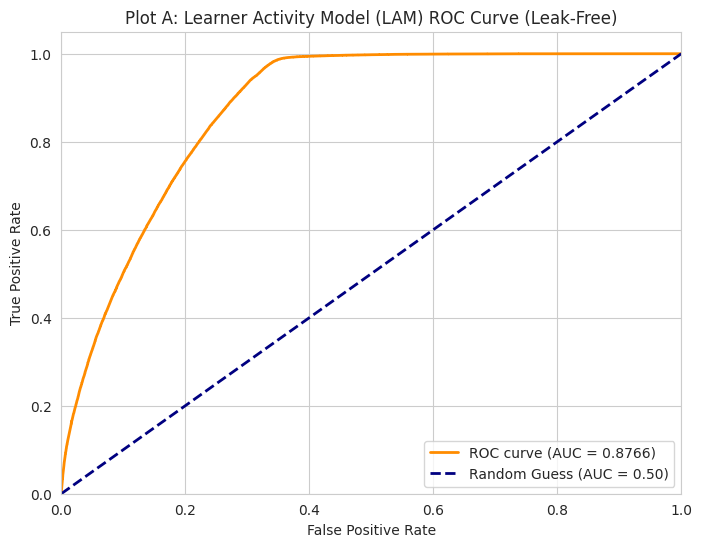

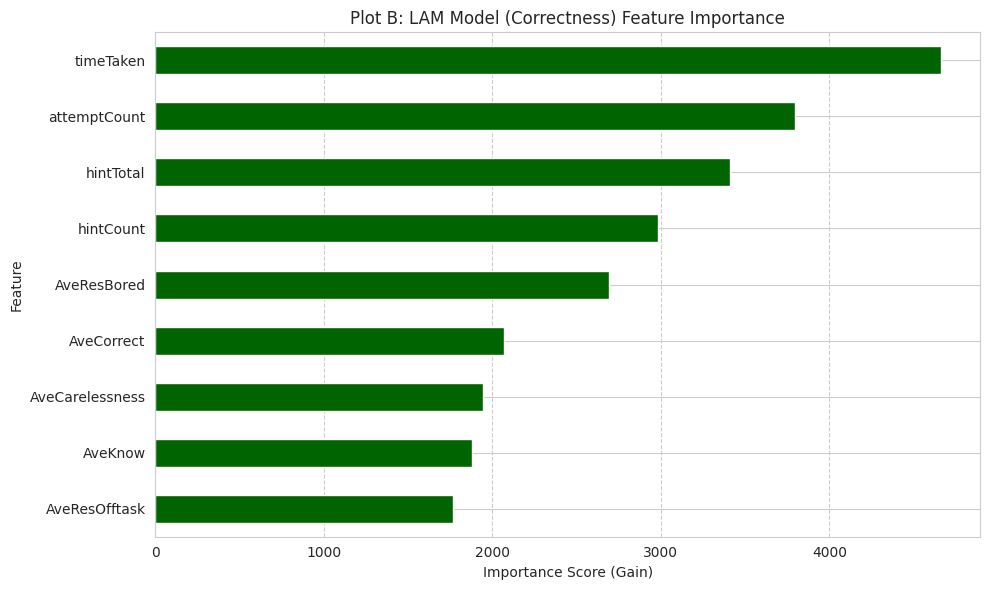

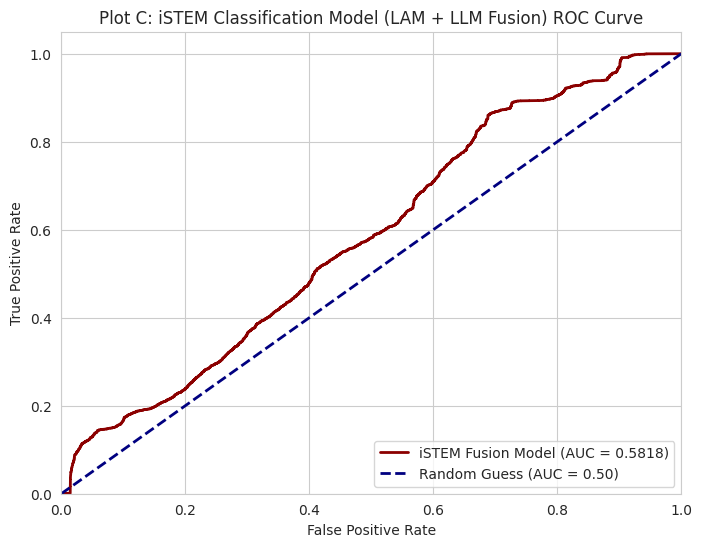

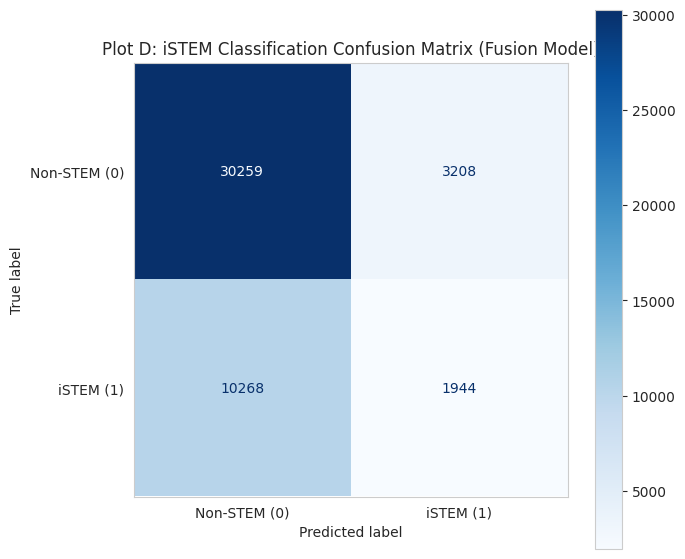

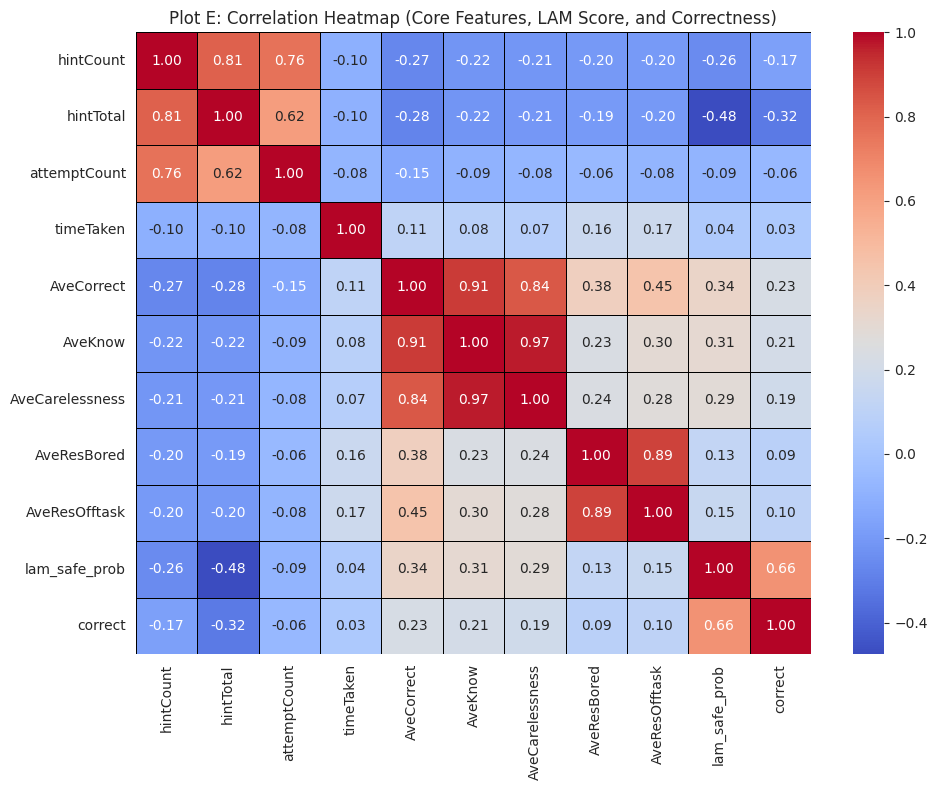

Running t-SNE on 20000 LLM embedding samples (may take a moment)...


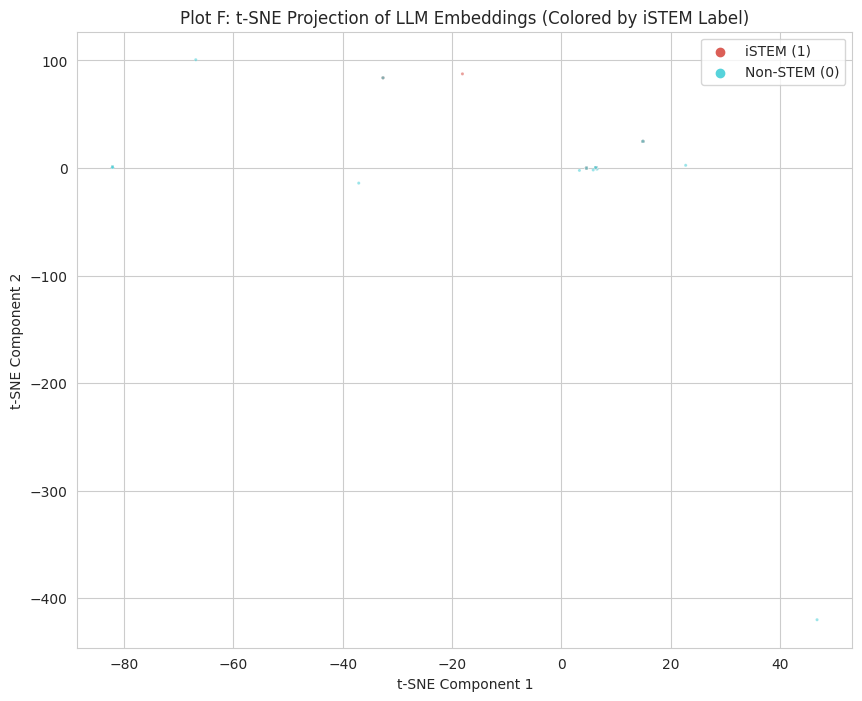


All 6 plots have been generated.


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import lightgbm as lgb
import joblib

# --- Helper function for loading objects (REPLACE IF NECESSARY) ---
def load_obj(path):
    """Placeholder for loading saved models/objects."""
    try:
        return joblib.load(path)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        print("Please ensure your 'load_obj' function is correctly defined or models are in the right directory.")
        raise

# Assuming PATHS["out_dir"] is defined and models are saved there
OUT_DIR = PATHS["out_dir"]

# --- 1. Load the Best Models and Data Subsets ---
print("1. Loading models and preparing data subsets...")

# LAM Model (Correctness)
try:
    safe_clf = load_obj(os.path.join(OUT_DIR, "lam_safe_lgb.pkl"))
except:
    print("Warning: Could not load lam_safe_lgb.pkl. Please ensure it is saved.")

# iSTEM Model (Robust Final Tune)
try:
    istem_clf = load_obj(os.path.join(OUT_DIR, "final_iSTEM_model_fusion_robust.pkl"))
except:
    print("Warning: Could not load final_iSTEM_model_fusion_robust.pkl. Please ensure it is saved.")

# Data Preparation for Plotting (Using the Imbalance-Corrected Subset)
mask_val = val_df["isSTEM"].notna()
y_istem_val = val_df.loc[mask_val, "isSTEM"].values.astype(int)

# --- 2. Generate Predictions ---
print("2. Generating predictions...")

# LAM Predictions (on leak-free subset X_val_safe)
lam_probs = safe_clf.predict_proba(X_val_safe)[:, 1]

# iSTEM Predictions (on fusion subset X_val_istem)
X_val_istem = X_fusion_val[mask_val.values]
istem_probs = istem_clf.predict_proba(X_val_istem)[:, 1]
istem_preds = (istem_probs > 0.5).astype(int)


# ===================================================================
# PLOTS START HERE
# ===================================================================
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("\n3. Generating Plots...")

# -------------------------------------------------------------------
# Plot A: LAM Model (Correctness) ROC Curve
# -------------------------------------------------------------------
fpr_lam, tpr_lam, _ = roc_curve(y_val, lam_probs)
roc_auc_lam = auc(fpr_lam, tpr_lam)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lam, tpr_lam, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_lam:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Plot A: Learner Activity Model (LAM) ROC Curve (Leak-Free)')
plt.legend(loc="lower right")
plt.show()

# -------------------------------------------------------------------
# Plot B: LAM Model Feature Importance
# -------------------------------------------------------------------
features = list(fusion_feature_cols)  # The 9 safe features
importance = safe_clf.feature_importances_
feature_importance = pd.Series(importance, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='darkgreen')
plt.title('Plot B: LAM Model (Correctness) Feature Importance')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Plot C: iSTEM Model (Fusion) ROC Curve
# -------------------------------------------------------------------
fpr_istem, tpr_istem, _ = roc_curve(y_istem_val, istem_probs)
roc_auc_istem = auc(fpr_istem, tpr_istem)

plt.figure(figsize=(8, 6))
plt.plot(fpr_istem, tpr_istem, color='darkred', lw=2, label=f'iSTEM Fusion Model (AUC = {roc_auc_istem:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Plot C: iSTEM Classification Model (LAM + LLM Fusion) ROC Curve')
plt.legend(loc="lower right")
plt.show()

# -------------------------------------------------------------------
# Plot D: iSTEM Model Confusion Matrix
# -------------------------------------------------------------------
cm = confusion_matrix(y_istem_val, istem_preds)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-STEM (0)', 'iSTEM (1)'])

fig, ax = plt.subplots(figsize=(7, 7))
cm_display.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
ax.set_title('Plot D: iSTEM Classification Confusion Matrix (Fusion Model)')
plt.grid(False)
plt.show()

# -------------------------------------------------------------------
# Plot E: Core Feature Correlation Heatmap
# -------------------------------------------------------------------
# Ensure all columns exist in fusion_val_rows
core_cols = list(fusion_feature_cols) + ["lam_safe_prob", "correct"]
# Filter for only the columns we need for the correlation
corr_df_subset = fusion_val_rows[core_cols].copy()

plt.figure(figsize=(10, 8))
correlation_matrix = corr_df_subset.corr()
# We are mainly interested in the correlations with 'correct' and 'lam_safe_prob'
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Plot E: Correlation Heatmap (Core Features, LAM Score, and Correctness)')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Plot F: LLM Embeddings t-SNE Projection
# -------------------------------------------------------------------
# LLM features are the last 384 columns of X_fusion_val
llm_embeddings_val = X_fusion_val[:, -384:] 

# Select a smaller sample for t-SNE (e.g., 20,000 points)
sample_size = min(20000, len(y_istem_val))
np.random.seed(42)
sample_indices = np.random.choice(len(y_istem_val), size=sample_size, replace=False)

X_sample = llm_embeddings_val[sample_indices]
y_sample = y_istem_val[sample_indices]
labels = pd.Series(y_sample).map({0: 'Non-STEM (0)', 1: 'iSTEM (1)'})

print(f"Running t-SNE on {sample_size} LLM embedding samples (may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels,
    palette=sns.color_palette("hls", 2),
    legend="full",
    alpha=0.6,
    s=5 # Small marker size for large number of points
)
plt.title('Plot F: t-SNE Projection of LLM Embeddings (Colored by iSTEM Label)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

print("\nAll 6 plots have been generated.")

1. Loading all iSTEM models and data...
2. Calculating metrics...
3. Generating Comparative Plot for iSTEM Models...


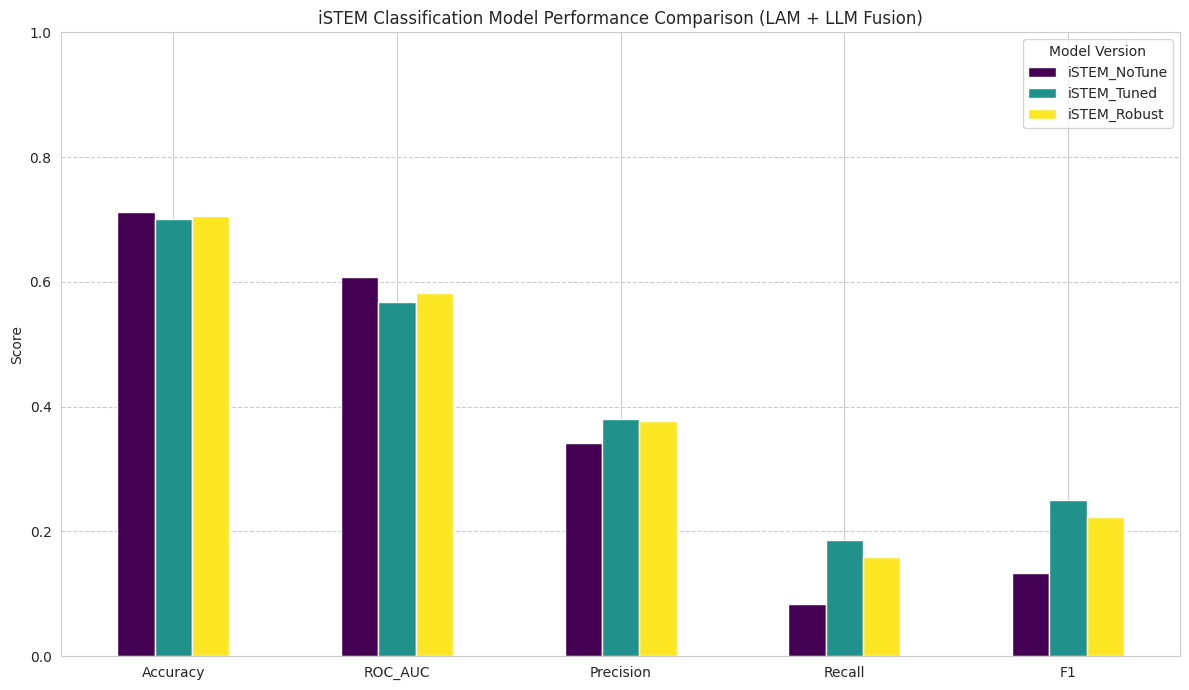


--- Summary Table of All Model Metrics ---
| Model           |   Accuracy |   ROC_AUC |   Precision_iSTEM |   Recall_iSTEM |   F1_iSTEM |   Precision_Correct |   Recall_Correct |   F1_Correct |
|:----------------|-----------:|----------:|------------------:|---------------:|-----------:|--------------------:|-----------------:|-------------:|
| iSTEM_NoTune    |     0.7121 |    0.6080 |            0.3419 |         0.0832 |     0.1338 |            nan      |         nan      |     nan      |
| iSTEM_Tuned     |     0.7014 |    0.5673 |            0.3805 |         0.1865 |     0.2503 |            nan      |         nan      |     nan      |
| iSTEM_Robust    |     0.7050 |    0.5818 |            0.3773 |         0.1592 |     0.2239 |            nan      |         nan      |     nan      |
| LAM_Correctness |     0.7874 |    0.8766 |          nan      |       nan      |   nan      |              0.6651 |           0.8460 |       0.7447 |


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

# --- Helper function for loading objects (REPLACE IF NECESSARY) ---
def load_obj(path):
    """Placeholder for loading saved models/objects."""
    return joblib.load(path)

# Assuming PATHS["out_dir"] is defined
OUT_DIR = PATHS["out_dir"]

# --- 1. Load All Models and Data Subsets ---
print("1. Loading all iSTEM models and data...")

# Load all three iSTEM models for comparison
try:
    istem_models = {
        "iSTEM_NoTune": load_obj(os.path.join(OUT_DIR, "final_iSTEM_model_fusion.pkl")),
        "iSTEM_Tuned": load_obj(os.path.join(OUT_DIR, "final_iSTEM_model_fusion_tuned.pkl")),
        "iSTEM_Robust": load_obj(os.path.join(OUT_DIR, "final_iSTEM_model_fusion_robust.pkl"))
    }
except Exception as e:
    print(f"Error loading models: {e}. Ensure all three .pkl files are saved from previous runs.")
    
# Data Prep (iSTEM Validation Subset)
mask_val = val_df["isSTEM"].notna()
y_istem_val = val_df.loc[mask_val, "isSTEM"].values.astype(int)
X_val_istem = X_fusion_val[mask_val.values]

# LAM Model for completeness
try:
    safe_clf = load_obj(os.path.join(OUT_DIR, "lam_safe_lgb.pkl"))
except:
    print("Warning: Could not load LAM model.")


# --- 2. Calculate Metrics for All Models ---
print("2. Calculating metrics...")

results = []

# --- A. iSTEM Models Metrics ---
for name, model in istem_models.items():
    probs = model.predict_proba(X_val_istem)[:, 1]
    preds = (probs > 0.5).astype(int)
    
    # Calculate Class 1 (iSTEM) metrics specifically
    report = classification_report(y_istem_val, preds, output_dict=True, zero_division=0)
    
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_istem_val, preds),
        "ROC_AUC": roc_auc_score(y_istem_val, probs),
        "Precision_iSTEM": report['1']['precision'],
        "Recall_iSTEM": report['1']['recall'],
        "F1_iSTEM": report['1']['f1-score'],
    }
    results.append(metrics)

# --- B. LAM Model Metrics (for comparison) ---
lam_probs = safe_clf.predict_proba(X_val_safe)[:, 1]
lam_preds = (lam_probs > 0.5).astype(int)
lam_report = classification_report(y_val, lam_preds, output_dict=True, zero_division=0)

lam_metrics = {
    "Model": "LAM_Correctness",
    "Accuracy": accuracy_score(y_val, lam_preds),
    "ROC_AUC": roc_auc_score(y_val, lam_probs),
    "Precision_iSTEM": np.nan, # Not applicable (Target is 'correct', not 'iSTEM')
    "Recall_iSTEM": np.nan,
    "F1_iSTEM": np.nan,
}
# Since LAM is a correctness model, we'll focus on its main metrics
lam_metrics['Precision_Correct'] = lam_report['1']['precision']
lam_metrics['Recall_Correct'] = lam_report['1']['recall']
lam_metrics['F1_Correct'] = lam_report['1']['f1-score']

results.append(lam_metrics)

results_df = pd.DataFrame(results)

# --- 3. Plotting Comparative Bar Chart (iSTEM Models) ---
print("3. Generating Comparative Plot for iSTEM Models...")

plot_df = results_df.set_index('Model').loc[['iSTEM_NoTune', 'iSTEM_Tuned', 'iSTEM_Robust']].T.drop(['Precision_Correct', 'Recall_Correct', 'F1_Correct'], errors='ignore')

# Rename columns for clarity in the plot
plot_df.index = plot_df.index.str.replace('_iSTEM', '')

# Plotting
plot_df.plot(kind='bar', figsize=(12, 7), colormap='viridis')
plt.title('iSTEM Classification Model Performance Comparison (LAM + LLM Fusion)')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.legend(title='Model Version')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("\n--- Summary Table of All Model Metrics ---")
print(results_df.to_markdown(index=False, floatfmt=".4f"))

1. Loading all models and preparing data subsets...
2. Calculating metrics for all four models...

3. Generating Separate Plots...


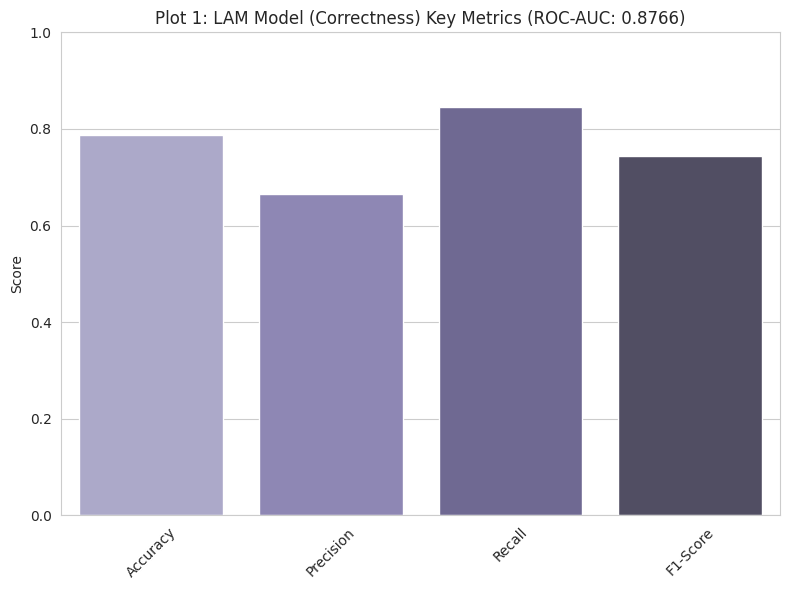

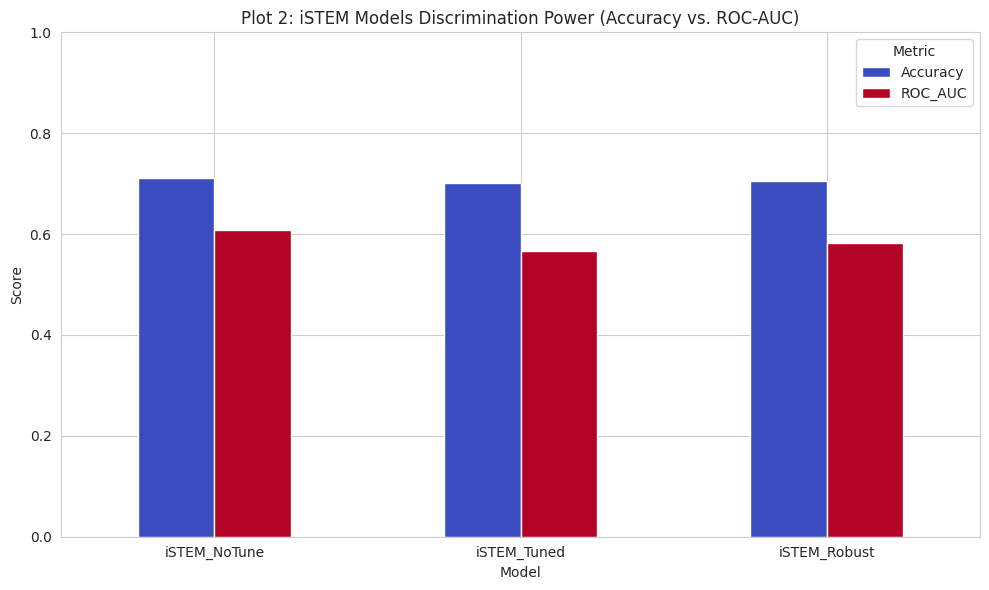

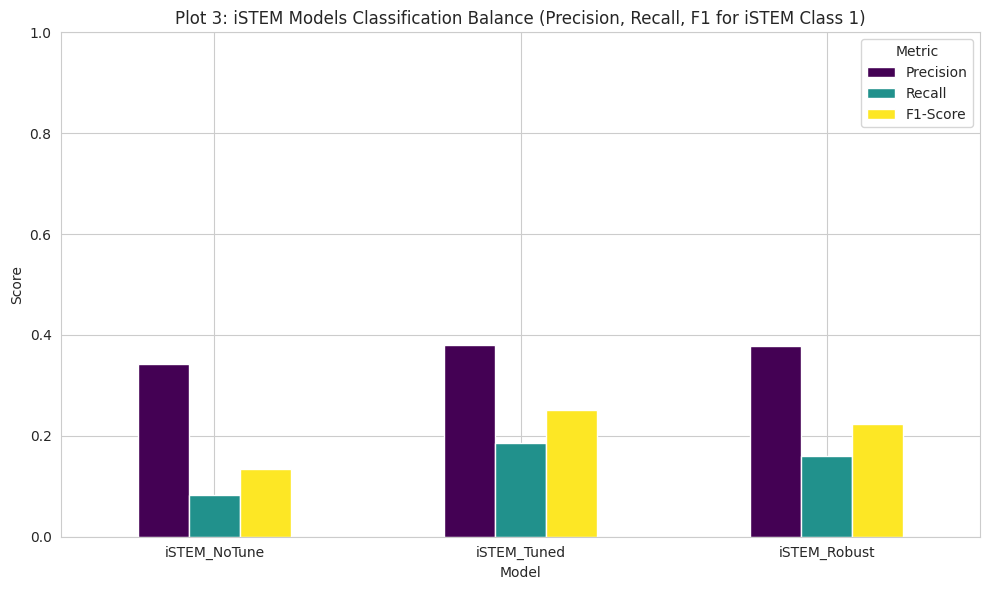


--- Summary Table of All Model Metrics ---
| Model           |   Accuracy |   ROC_AUC |   Precision |   Recall |   F1-Score |
|:----------------|-----------:|----------:|------------:|---------:|-----------:|
| iSTEM_NoTune    |     0.7121 |    0.6080 |      0.3419 |   0.0832 |     0.1338 |
| iSTEM_Tuned     |     0.7014 |    0.5673 |      0.3805 |   0.1865 |     0.2503 |
| iSTEM_Robust    |     0.7050 |    0.5818 |      0.3773 |   0.1592 |     0.2239 |
| LAM_Correctness |     0.7874 |    0.8766 |      0.6651 |   0.8460 |     0.7447 |


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report

# --- Helper function for loading objects (REPLACE IF NECESSARY) ---
def load_obj(path):
    """Placeholder for loading saved models/objects."""
    return joblib.load(path)

# Assuming PATHS["out_dir"] is defined
OUT_DIR = PATHS["out_dir"]

# --- 1. Load All Models and Data Subsets ---
print("1. Loading all models and preparing data subsets...")

# Load all three iSTEM models for comparison
try:
    istem_models = {
        "iSTEM_NoTune": load_obj(os.path.join(OUT_DIR, "final_iSTEM_model_fusion.pkl")),
        "iSTEM_Tuned": load_obj(os.path.join(OUT_DIR, "final_iSTEM_model_fusion_tuned.pkl")),
        "iSTEM_Robust": load_obj(os.path.join(OUT_DIR, "final_iSTEM_model_fusion_robust.pkl"))
    }
    safe_clf = load_obj(os.path.join(OUT_DIR, "lam_safe_lgb.pkl"))
except Exception as e:
    print(f"Error loading models. Please ensure all four .pkl files are saved. Error: {e}")
    raise

# Data Prep
mask_val = val_df["isSTEM"].notna()
y_istem_val = val_df.loc[mask_val, "isSTEM"].values.astype(int)
X_val_istem = X_fusion_val[mask_val.values]

# --- 2. Calculate Metrics for All Models ---
print("2. Calculating metrics for all four models...")

results = []

# --- A. iSTEM Models Metrics ---
for name, model in istem_models.items():
    probs = model.predict_proba(X_val_istem)[:, 1]
    preds = (probs > 0.5).astype(int)
    
    # Calculate metrics for the minority class '1' (iSTEM)
    report = classification_report(y_istem_val, preds, output_dict=True, zero_division=0)
    
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_istem_val, preds),
        "ROC_AUC": roc_auc_score(y_istem_val, probs),
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-Score": report['1']['f1-score'],
    }
    results.append(metrics)

# --- B. LAM Model Metrics (Correctness Target) ---
lam_probs = safe_clf.predict_proba(X_val_safe)[:, 1]
lam_preds = (lam_probs > 0.5).astype(int)
lam_report = classification_report(y_val, lam_preds, output_dict=True, zero_division=0)

lam_metrics = {
    "Model": "LAM_Correctness",
    "Accuracy": accuracy_score(y_val, lam_preds),
    "ROC_AUC": roc_auc_score(y_val, lam_probs),
    "Precision": lam_report['1']['precision'],
    "Recall": lam_report['1']['recall'],
    "F1-Score": lam_report['1']['f1-score'],
}

results_df = pd.DataFrame(results + [lam_metrics])
results_df.set_index('Model', inplace=True)


# ===================================================================
# PLOTS START HERE
# ===================================================================
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("\n3. Generating Separate Plots...")

# --- Plot 1: LAM Model (Correctness) Performance ---
lam_df = results_df.loc[['LAM_Correctness']].drop(columns=['ROC_AUC']).T
lam_df.columns = ['LAM_Correctness']

plt.figure(figsize=(8, 6))
sns.barplot(x=lam_df.index, y=lam_df['LAM_Correctness'], palette='Purples_d')
plt.title('Plot 1: LAM Model (Correctness) Key Metrics (ROC-AUC: {:.4f})'.format(results_df.loc['LAM_Correctness', 'ROC_AUC']))
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- Plot 2: iSTEM Models - Discrimination Power (ROC and Accuracy) ---
istem_roc_acc_df = results_df.loc[['iSTEM_NoTune', 'iSTEM_Tuned', 'iSTEM_Robust']][['Accuracy', 'ROC_AUC']]
istem_roc_acc_df.plot(kind='bar', figsize=(10, 6), colormap='coolwarm')
plt.title('Plot 2: iSTEM Models Discrimination Power (Accuracy vs. ROC-AUC)')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


# --- Plot 3: iSTEM Models - Balanced Classification (P, R, F1 for iSTEM Class 1) ---
istem_prf_df = results_df.loc[['iSTEM_NoTune', 'iSTEM_Tuned', 'iSTEM_Robust']][['Precision', 'Recall', 'F1-Score']]
istem_prf_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Plot 3: iSTEM Models Classification Balance (Precision, Recall, F1 for iSTEM Class 1)')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

print("\n--- Summary Table of All Model Metrics ---")
print(results_df.to_markdown(floatfmt=".4f"))

iSTEM Robust model probabilities generated.

--- Generating Advanced and Error Analysis Plots ---


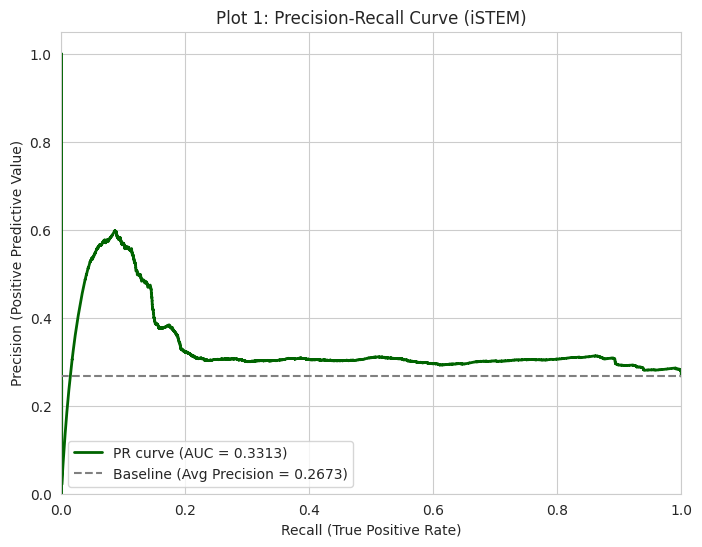

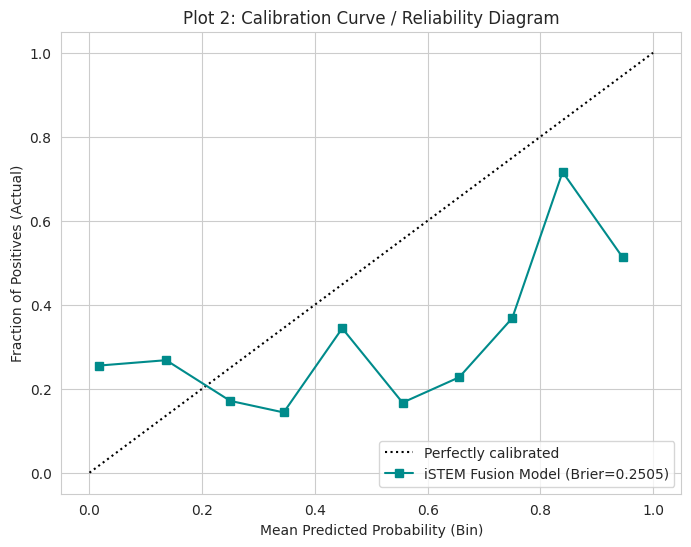

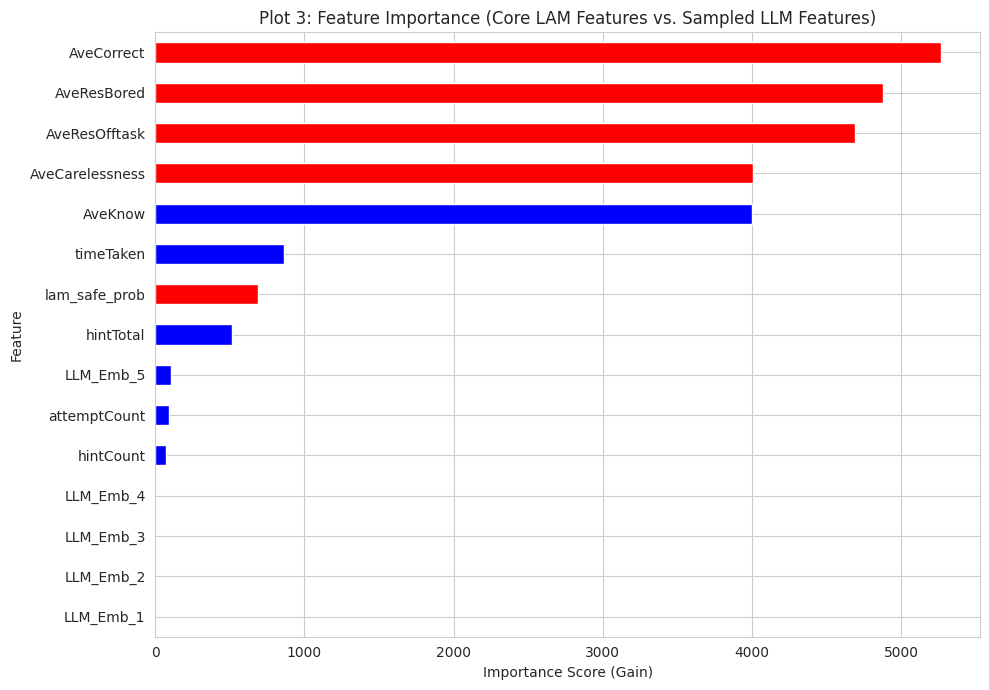

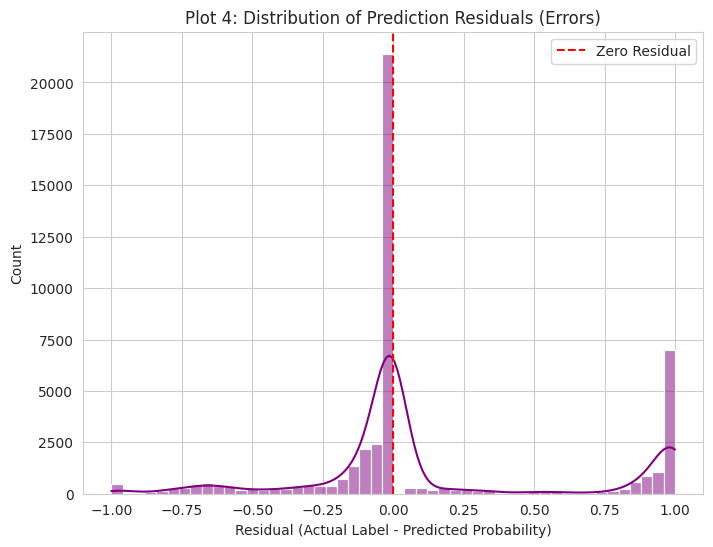

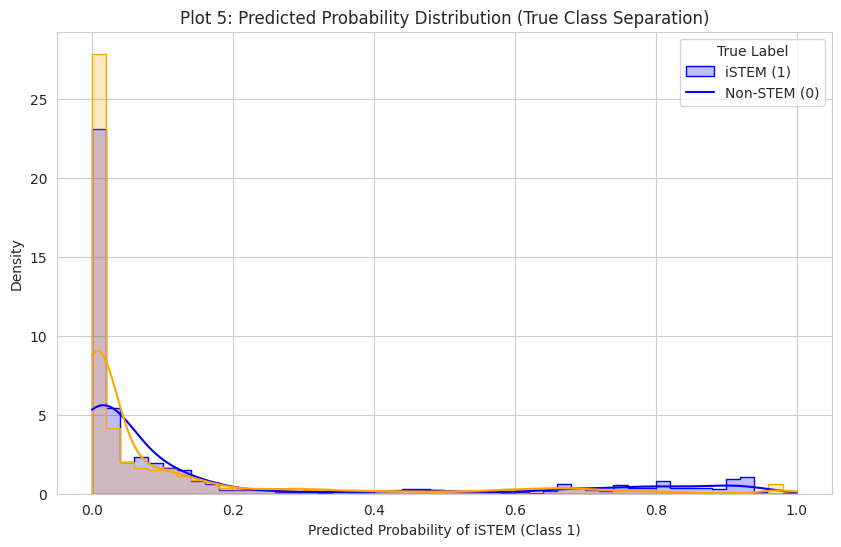


All advanced plots have been successfully generated.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import joblib

# --- Data and Model Prep (Requires variables from previous runs) ---
# Assuming istem_clf is the final robust model loaded
# Assuming istem_probs, X_val_istem, y_istem_val are available

# Get predictions from the final robust iSTEM model
# NOTE: Run this block ONLY after the models have been loaded in a prior step.
try:
    istem_probs = istem_clf.predict_proba(X_val_istem)[:, 1]
    print("iSTEM Robust model probabilities generated.")
except NameError:
    print("Error: Models/data (e.g., istem_clf, X_val_istem) not defined. Ensure previous code blocks ran successfully.")
    raise

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("\n--- Generating Advanced and Error Analysis Plots ---")

# -------------------------------------------------------------------
# Plot 1: Precision-Recall Curve (PRC) - Essential for Imbalance
# -------------------------------------------------------------------
precision, recall, thresholds = precision_recall_curve(y_istem_val, istem_probs)
pr_auc = auc(recall, precision)
baseline = np.sum(y_istem_val) / len(y_istem_val)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkgreen', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='gray', label=f'Baseline (Avg Precision = {baseline:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Plot 1: Precision-Recall Curve (iSTEM)')
plt.legend(loc="lower left")
plt.show()

# -------------------------------------------------------------------
# Plot 2: Calibration Curve (Reliability Diagram)
# -------------------------------------------------------------------
fraction_of_positives, mean_predicted_value = calibration_curve(y_istem_val, istem_probs, n_bins=10)
brier = brier_score_loss(y_istem_val, istem_probs)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.plot(mean_predicted_value, fraction_of_positives, "s-", color='darkcyan', label=f'iSTEM Fusion Model (Brier={brier:.4f})')
plt.xlabel("Mean Predicted Probability (Bin)")
plt.ylabel("Fraction of Positives (Actual)")
plt.title('Plot 2: Calibration Curve / Reliability Diagram')
plt.legend(loc="lower right")
plt.show()

# -------------------------------------------------------------------
# Plot 3: Feature Importance (Comparing LAM vs. LLM)
# -------------------------------------------------------------------
importance = istem_clf.feature_importances_
n_core = len(fusion_feature_cols) + 1 # 9 core + 1 lam_safe_prob
n_llm_samples = 5 # Show top 5 LLM features for visualization
n_features_total = n_core + n_llm_samples

# Create feature names for the first n_core (behavioral) features
feature_names = list(fusion_feature_cols) + ["lam_safe_prob"] 

# Add names for the LLM features
for i in range(n_llm_samples):
    feature_names.append(f"LLM_Emb_{i+1}")

# Select the importance scores for the features to be plotted
importance_subset = np.hstack([importance[:n_core], importance[n_core:n_core + n_llm_samples]])

# Sort for plotting
feature_importance = pd.Series(importance_subset, index=feature_names).sort_values(ascending=False)
top_n_importance = feature_importance.head(n_features_total) # Re-limit to the top of the subset

plt.figure(figsize=(10, 7))
colors = ['r' if 'LLM' in f else 'b' for f in top_n_importance.index]
top_n_importance.sort_values(ascending=True).plot(kind='barh', color=colors)
plt.title('Plot 3: Feature Importance (Core LAM Features vs. Sampled LLM Features)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Plot 4: Residual Distribution Plot (Error Analysis)
# -------------------------------------------------------------------
residuals = y_istem_val - istem_probs

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.axvline(x=0, color='r', linestyle='--', label='Zero Residual')
plt.title('Plot 4: Distribution of Prediction Residuals (Errors)')
plt.xlabel('Residual (Actual Label - Predicted Probability)')
plt.ylabel('Count')
plt.legend()
plt.show()

# -------------------------------------------------------------------
# Plot 5: Predicted Probability Distribution (Separation Visualization)
# -------------------------------------------------------------------
df_probs = pd.DataFrame({
    'Probability': istem_probs,
    'True_Label': y_istem_val
})

plt.figure(figsize=(10, 6))
sns.histplot(data=df_probs, x='Probability', hue='True_Label', bins=50, kde=True,
             palette={0: 'orange', 1: 'blue'}, element='step', common_norm=False,
             stat='density')
plt.title('Plot 5: Predicted Probability Distribution (True Class Separation)')
plt.xlabel('Predicted Probability of iSTEM (Class 1)')
plt.ylabel('Density')
plt.legend(title='True Label', labels=['iSTEM (1)', 'Non-STEM (0)'])
plt.show()

print("\nAll advanced plots have been successfully generated.")

iSTEM Robust model probabilities generated.

--- Generating FINAL Advanced Plots (FIXED PLOT 5) ---


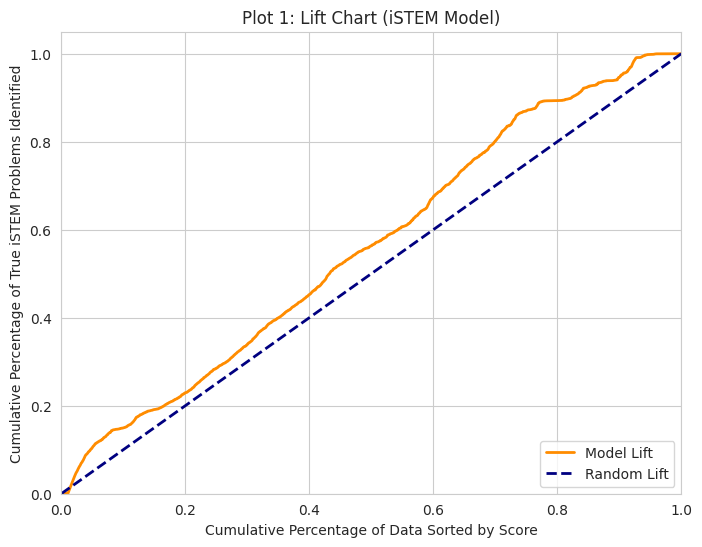

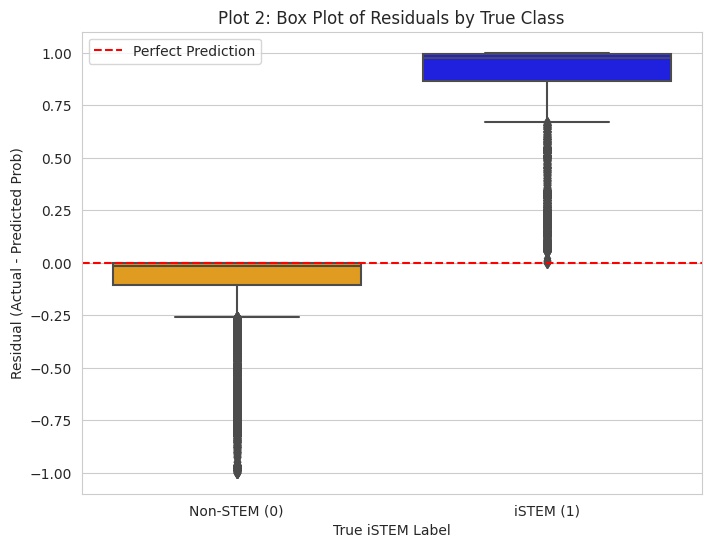

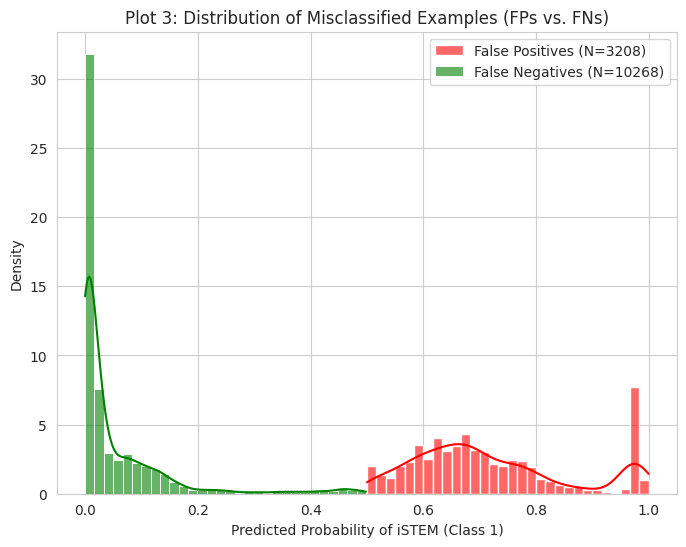

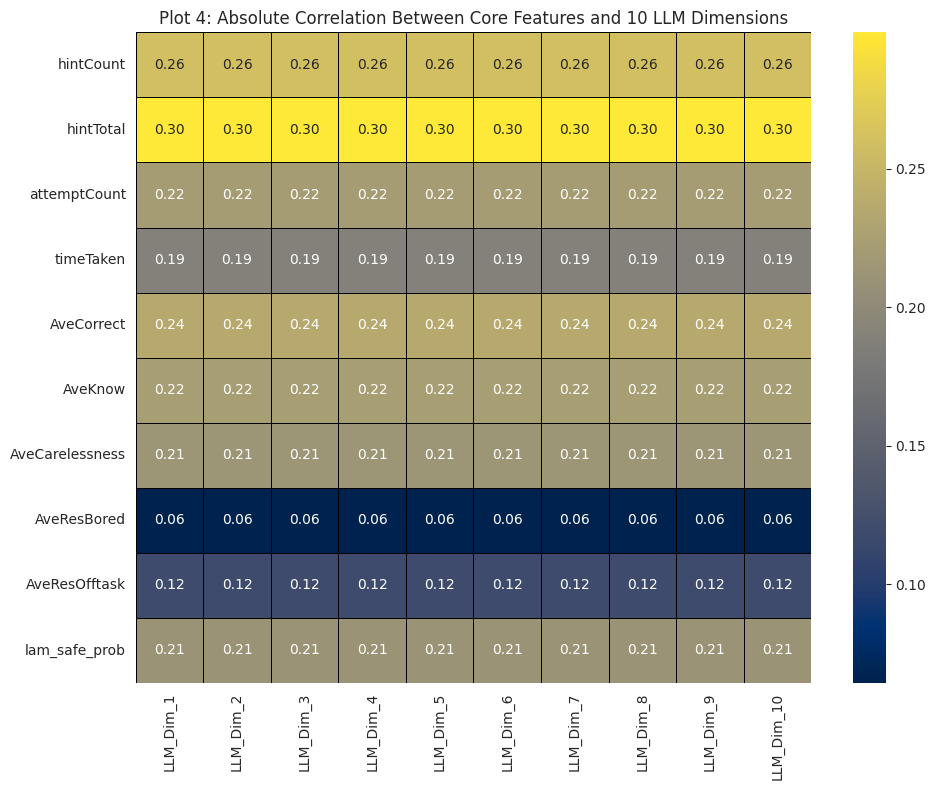


All final plots generated successfully.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.stats import iqr
import joblib

# --- Data and Model Prep (Requires variables from previous runs) ---
# Assuming istem_clf is the final robust model loaded
try:
    istem_probs = istem_clf.predict_proba(X_val_istem)[:, 1]
    istem_preds = (istem_probs > 0.5).astype(int)
    print("iSTEM Robust model probabilities generated.")
except NameError:
    print("Error: Models/data (e.g., istem_clf, X_val_istem) not defined. Ensure previous code blocks ran successfully.")
    raise

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("\n--- Generating FINAL Advanced Plots (FIXED PLOT 5) ---")

# -------------------------------------------------------------------
# Plot 1: Lift Chart (Business Value)
# -------------------------------------------------------------------
df_lift = pd.DataFrame({'Target': y_istem_val, 'Score': istem_probs})
df_lift = df_lift.sort_values(by='Score', ascending=False).reset_index(drop=True)
df_lift['Cumulative_Target'] = df_lift['Target'].cumsum()
df_lift['Cumulative_Percent'] = df_lift.index.values / len(df_lift)
total_positives = df_lift['Target'].sum()

plt.figure(figsize=(8, 6))
plt.plot(df_lift['Cumulative_Percent'], df_lift['Cumulative_Target'] / total_positives, 
         color='darkorange', lw=2, label='Model Lift')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Lift')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Cumulative Percentage of Data Sorted by Score')
plt.ylabel('Cumulative Percentage of True iSTEM Problems Identified')
plt.title('Plot 1: Lift Chart (iSTEM Model)')
plt.legend(loc="lower right")
plt.show()

# -------------------------------------------------------------------
# Plot 2: Box Plot of Residuals (Distribution of Errors)
# -------------------------------------------------------------------
residuals = y_istem_val - istem_probs
df_residual = pd.DataFrame({
    'Residual': residuals,
    'True_Label': y_istem_val
})
df_residual['True_Label'] = df_residual['True_Label'].map({0: 'Non-STEM (0)', 1: 'iSTEM (1)'})

plt.figure(figsize=(8, 6))
sns.boxplot(x='True_Label', y='Residual', data=df_residual, palette=['orange', 'blue'])
plt.axhline(0, color='r', linestyle='--', label='Perfect Prediction')
plt.title('Plot 2: Box Plot of Residuals by True Class')
plt.xlabel('True iSTEM Label')
plt.ylabel('Residual (Actual - Predicted Prob)')
plt.legend()
plt.show()

# -------------------------------------------------------------------
# Plot 3: Distribution of Misclassified Examples
# -------------------------------------------------------------------
errors = pd.DataFrame({
    'Probability': istem_probs,
    'True_Label': y_istem_val,
    'Predicted_Label': istem_preds
})

# Filter for FPs and FNs
FP = errors[(errors['True_Label'] == 0) & (errors['Predicted_Label'] == 1)]
FN = errors[(errors['True_Label'] == 1) & (errors['Predicted_Label'] == 0)]

plt.figure(figsize=(8, 6))
sns.histplot(data=FP, x='Probability', bins=30, color='red', label=f'False Positives (N={len(FP)})', kde=True, stat='density', alpha=0.6)
sns.histplot(data=FN, x='Probability', bins=30, color='green', label=f'False Negatives (N={len(FN)})', kde=True, stat='density', alpha=0.6)

plt.title('Plot 3: Distribution of Misclassified Examples (FPs vs. FNs)')
plt.xlabel('Predicted Probability of iSTEM (Class 1)')
plt.ylabel('Density')
plt.legend()
plt.show()

# -------------------------------------------------------------------
# Plot 4: Correlation of Features with LLM Embeddings (Deep Dive) - FIXED LOGIC
# -------------------------------------------------------------------
# core_df is already defined from X_val_istem[:, :N_CORE_FEATURES]
# We must use the LLM portion of X_val_istem which is already masked/filtered.
n_llm_dims = 10
n_core_cols = len(fusion_feature_cols) + 1 # 9 core + 1 lam_safe_prob

# FIXED: Extract LLM embeddings from the masked array X_val_istem
llm_embeddings_filtered = X_val_istem[:, n_core_cols:] 
core_df = pd.DataFrame(X_val_istem[:, :n_core_cols], columns=list(fusion_feature_cols) + ["lam_safe_prob"])

# Compute correlation matrix between core features and first 10 LLM embedding dimensions
# Since X_val_istem is already filtered, the shapes now match (45679 rows)
# Concatenate arrays along the column axis (axis=1) for correlation
combined_array = np.concatenate((core_df.values, llm_embeddings_filtered[:, :n_llm_dims]), axis=1)

# Compute correlation matrix (rowvar=False means features are columns)
llm_corr_matrix = np.corrcoef(combined_array, rowvar=False)

# Extract the block showing correlation between core features and LLM dims
# This block is at the intersection of core feature columns and LLM dimension columns
llm_corr_block = llm_corr_matrix[n_core_cols:, :n_core_cols].T

llm_corr_df = pd.DataFrame(llm_corr_block, 
                           index=core_df.columns, 
                           columns=[f'LLM_Dim_{i+1}' for i in range(n_llm_dims)])

plt.figure(figsize=(10, 8))
sns.heatmap(llm_corr_df.abs(), annot=True, cmap='cividis', fmt=".2f", linewidths=.5, linecolor='black')
plt.title(f'Plot 4: Absolute Correlation Between Core Features and {n_llm_dims} LLM Dimensions')
plt.tight_layout()
plt.show()

print("\nAll final plots generated successfully.")

--- Generating Final Niche Plot: Threshold Tuning ---


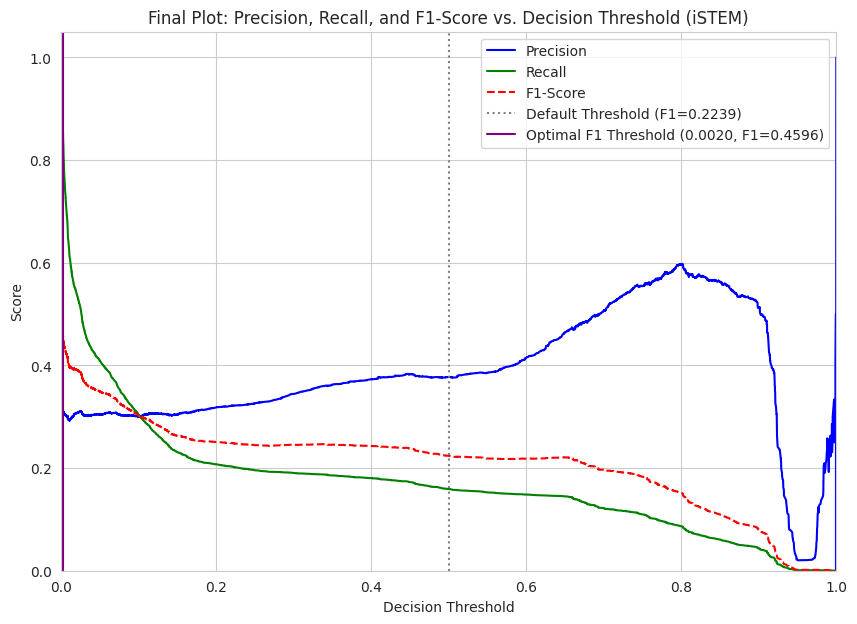

Threshold Tuning Plot generated successfully.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, f1_score

# --- Data and Model Prep (Requires variables from previous runs) ---
# Assuming istem_probs and y_istem_val are available

print("--- Generating Final Niche Plot: Threshold Tuning ---")

# 1. Calculate Precision, Recall, and F1 for a range of thresholds
precision, recall, thresholds = precision_recall_curve(y_istem_val, istem_probs)

# Add a 1.0 threshold for completeness
thresholds = np.append(thresholds, 1.0)
f1_scores = [f1_score(y_istem_val, (istem_probs >= t).astype(int), zero_division=0) for t in thresholds]

# Create a DataFrame for easy plotting
threshold_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_scores
}).set_index('Threshold')

# 2. Find optimal thresholds (Max F1)
optimal_threshold_f1 = threshold_df['F1-Score'].idxmax()
max_f1 = threshold_df['F1-Score'].max()
default_f1 = f1_score(y_istem_val, (istem_probs >= 0.5).astype(int), zero_division=0)

# 3. Plotting
plt.figure(figsize=(10, 7))
plt.plot(threshold_df.index, threshold_df['Precision'], label='Precision', color='blue')
plt.plot(threshold_df.index, threshold_df['Recall'], label='Recall', color='green')
plt.plot(threshold_df.index, threshold_df['F1-Score'], label='F1-Score', color='red', linestyle='--')

# Highlight default 0.5 threshold
plt.axvline(0.5, color='gray', linestyle=':', label=f'Default Threshold (F1={default_f1:.4f})')

# Highlight optimal threshold
plt.axvline(optimal_threshold_f1, color='purple', linestyle='-', 
            label=f'Optimal F1 Threshold ({optimal_threshold_f1:.4f}, F1={max_f1:.4f})')

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Final Plot: Precision, Recall, and F1-Score vs. Decision Threshold (iSTEM)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

print("Threshold Tuning Plot generated successfully.")

In [29]:
import os

# Assuming PATHS["out_dir"] is defined and train_df and val_df are in memory
OUT_DIR = PATHS["out_dir"]

# Save final processed DataFrames
train_df.to_csv(os.path.join(OUT_DIR, "train_final_processed.csv"), index=False)
val_df.to_csv(os.path.join(OUT_DIR, "val_final_processed.csv"), index=False)

print("✅ Saved train_df to train_final_processed.csv")
print("✅ Saved val_df to val_final_processed.csv")

✅ Saved train_df to train_final_processed.csv
✅ Saved val_df to val_final_processed.csv


In [30]:
import os
import shutil

# List of critical file types to download
critical_files = [
    "train_final_processed.csv",
    "val_final_processed.csv",
    "lam_safe_lgb.pkl",
    "final_iSTEM_model_fusion_robust.pkl",
    "X_fusion_train.npy",
    "X_fusion_val.npy",
    "LLM_emb_tr.npy",
    "LLM_emb_val.npy",
    "fusion_meta.pkl"
]

# Assuming files are in /kaggle/working/ or a similar path
print("Preparing to download files...")

# Display instructions specific to the environment (e.g., Colab or Jupyter)
try:
    # Google Colab specific download command
    from google.colab import files
    
    # Check if files exist and download them one by one
    for filename in critical_files:
        filepath = os.path.join("/kaggle/working/", filename)
        if os.path.exists(filepath):
            files.download(filepath)
            print(f"Downloaded: {filename}")
        else:
            print(f"Skipping: {filename} (File not found)")
            
    # Also download the cache folder which contains the SentenceTransformer model weights
    shutil.make_archive("llm_cache_backup", 'zip', "/kaggle/working/llm_cache/paraphrase-MiniLM-L6-v2")
    files.download("llm_cache_backup.zip")
    print("Downloaded: llm_cache_backup.zip (Contains SentenceTransformer weights)")

except ImportError:
    # Standard Jupyter/Kaggle notebook environments
    print("\n--- Download Instructions for Standard Notebooks ---")
    print("This environment does not support programmatic download. Please use the file browser panel (usually on the left) to manually download the following files:")
    
    all_output_files = [f for f in os.listdir("/kaggle/working/") if os.path.isfile(os.path.join("/kaggle/working/", f))]
    print("\nMODEL & FEATURE FILES (.pkl, .npy, .csv):")
    for f in all_output_files:
        if f.endswith(('.pkl', '.npy', '.csv')):
            print(f"- {f}")
            
    print("\nLLM CACHE FOLDER:")
    print("- llm_cache (Recommended: Right-click and download the entire folder, or zip it first)")
    
    # Optional: Zip all contents for a single download
    shutil.make_archive("FINAL_PROJECT_BACKUP", 'zip', "/kaggle/working/")
    print("\nAlternatively, download FINAL_PROJECT_BACKUP.zip which contains all files.")

Preparing to download files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: train_final_processed.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: fusion_meta.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: llm_cache_backup.zip (Contains SentenceTransformer weights)
